# Eval analysis

### imports

In [74]:
import logging
from dotenv import load_dotenv
from evals import Dataset
from evals.metrics import CollectMetrics
import warnings
from huggingface_hub.utils import _http
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Literal
import plotly.express as px
from plotly import subplots
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import ast
logger = logging.getLogger(__name__)

logging.getLogger(__name__).setLevel(logging.DEBUG)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


warnings.filterwarnings(
    "ignore",
    message=".*UNEXPECTED.*",
    #message = ".*Warning.*",
    category=UserWarning,
    module="transformers.modeling_utils"  
)
save_figures = False
load_dotenv()

True

### Loading Data

In [2]:
def load_results(dataset_name):
    ds = Dataset(dataset_name)
    cm = CollectMetrics()
    eval_res = ds.load_evaluation_results()
    all_eval_runs = cm.organize_runs_by_type(eval_res)
    coll_res = ds.load_results()
    all_collected_res = cm.organize_runs_by_type(coll_res)
    #DeepEval
    logger.info("Collecting DeepEval metrics...")
    deepeval_obs = []
    for runs in tqdm(all_eval_runs.values()):
        deepeval_obs.extend(cm.collect_deepeval_metrics(runs))
    #bert metrics
    logger.info("Collecting BERT metrics...")
    berts = []
    for runs in tqdm(all_eval_runs.values()):
        berts.extend(cm.collect_berts(runs))
    #Resource metrics
    logger.info(f'Collecting resource metrics...')
    gathered_res = ds.load_results()
    resource_obs = cm.collect_resource_metrics(list(gathered_res.values()))

    logger.info("Merging metrics into DataFrame...")
    df_de = pd.DataFrame([dp.model_dump() for dp in deepeval_obs])
    df_brt = pd.DataFrame([bert.model_dump() for bert in berts])
    df_rm = pd.DataFrame([rm.model_dump() for rm in resource_obs])
    drop = ["eval_run_id", 
            "name",
            #"query_id", "session_id", 
            ]
    on = ["llm_model", "dataset_name", 
            "query_id", "session_id", "agent_type",
            "session", "session_name"]

    df = pd.merge(df_de.drop(columns=drop, errors = "ignore"), df_rm.drop(columns=drop, errors = "ignore"), on = on,)
                                                                                                                
    df = pd.merge(df, df_brt.drop(columns=drop, errors = "ignore"), on = on)
    return df

In [43]:
if Path("cached_results.csv").exists():
    logger.info("Loading cached results from 'cached_results.csv'...")
    df = pd.read_csv("cached_results.csv")
else:
    try:
        df_thrd = load_results("THRD-2021-163881")
    except Exception as e:
        print(f"Error loading THRD results: {e}")

    try:
        df_tosl = load_results("TOSL-2024-125319-MIN")
    except Exception as e:
        print(f"Error loading TOSL results: {e}")
    
    df = pd.concat([df_thrd, df_tosl], ignore_index=True)

    df.to_csv("cached_results.csv", index=False)

INFO:__main__:Loading cached results from 'cached_results.csv'...


In [4]:
df.head()

,dataset_name,query_id,session_id,session,session_name,llm_model,agent_type,question_type,correctness,relevancy,...,total_tokens,llm_calls,bert_precision,bert_recall,bert_f1,s_bert_similarity,actual_output,expected_output,embedded_actual_output,embedded_expected_output
0,THRD-2021-163881,82d6385b-3f42-4c89-8df6-82cea426f45a,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,1.0,1.0,...,36225,2,0.629391,0.760249,0.688659,0.917468,"Ja, det er tatt forbehold i salgsoppgaven og k...",- Kjøpskontrakten inneholder en «som den er»-k...,"[0.004865377, 0.008909141, -0.003945247, -0.05...","[0.013837026, 0.016975842, -0.0038165622, -0.0..."
1,THRD-2021-163881,4839e2f2-4717-4f33-b04f-be81496b2648,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,1.0,1.0,...,21504,1,0.610427,0.771043,0.681398,0.905637,Her er en beskrivelse av aktørene i saken og d...,- Anders og Berit Kristiansen: saksøkere (kjøp...,"[-0.0039394367, 0.0054898914, 0.007177732, -0....","[-0.013774939, -0.0079543, -0.0017583347, -0.0..."
2,THRD-2021-163881,070f570b-f9d0-454f-90ca-84f66ede1a31,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,0.6,1.0,...,12064,1,0.659326,0.743674,0.698964,0.938199,"Kjøperne, Anders og Berit Kristiansen, har mot...",- Eierens opplysningsskjema: selger opplyste o...,"[0.0002993953, 0.01868615, -0.0101048965, -0.0...","[0.004011874, 0.025300551, -0.009952226, -0.04..."
3,THRD-2021-163881,335b247f-0a2b-4eef-85f8-5cc0e2c6a2e2,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,factual,0.6,1.0,...,25623,2,0.621907,0.748193,0.679230,0.939552,Basert på de tilgjengelige dokumentene er følg...,- Eneste formelt reklamerte mangel (per mars 2...,"[-0.009208715, 0.012256192, -0.006481587, -0.0...","[-0.011796225, 0.008586926, -0.010823273, -0.0..."
4,THRD-2021-163881,f3f226bb-eb5c-4b87-8d96-dfa425614f42,fce42233-a542-4489-895a-dcedc50b0820,0,Prosjekt-initialisering,google_gemini-2.5-flash,baseline_rag,summary,0.8,1.0,...,12911,2,0.683211,0.747082,0.713721,0.955617,Anders og Berit Kristiansen kjøpte eiendommen ...,- Anders og Berit Kristiansen kjøpte Fjellveie...,"[0.0013216397, 0.016857985, -0.009796431, -0.0...","[-0.005734375, 0.016356306, 0.0032262322, -0.0..."


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   dataset_name              899 non-null    object        
 1   query_id                  899 non-null    object        
 2   session_id                899 non-null    object        
 3   session                   899 non-null    int64         
 4   session_name              899 non-null    object        
 5   llm_model                 899 non-null    object        
 6   agent_type                899 non-null    object        
 7   question_type             899 non-null    object        
 8   correctness               899 non-null    float64       
 9   relevancy                 899 non-null    float64       
 10  completeness              551 non-null    float64       
 11  success                   899 non-null    bool          
 12  starttime             

In [5]:
def standardize_model_names(df):
    df.loc[df["llm_model"] == "qwen_Qwen/Qwen3-Next-80B-A3B-Instruct" , "llm_model"] = "Qwen3-Next-80B-A3B-Instruct"
    df.loc[df["llm_model"] == "qwen_Qwen/Qwen3.5-397B-A17B" , "llm_model"] = "Qwen3.5-397B-A17B"
    df.loc[df["llm_model"] == "zai_zai-org/GLM-5" , "llm_model"] = "GLM-5"
    df.loc[df["llm_model"] == "google_gemini-2.5-flash" , "llm_model"] = "gemini-2.5-flash"
    df.loc[df["llm_model"] == "google_gemini-2.5-pro" , "llm_model"] = "gemini-2.5-pro"

    models_to_keep = ["Qwen3.5-397B-A17B", "GLM-5", "gemini-2.5-flash", "gemini-2.5-pro"]
    df = df[df["llm_model"].isin(models_to_keep)]
standardize_model_names(df)
df["llm_model"].value_counts()

llm_model
gemini-2.5-flash     327
gemini-2.5-pro       186
Qwen3.5-397B-A17B    186
GLM-5                185
Name: count, dtype: int64

''

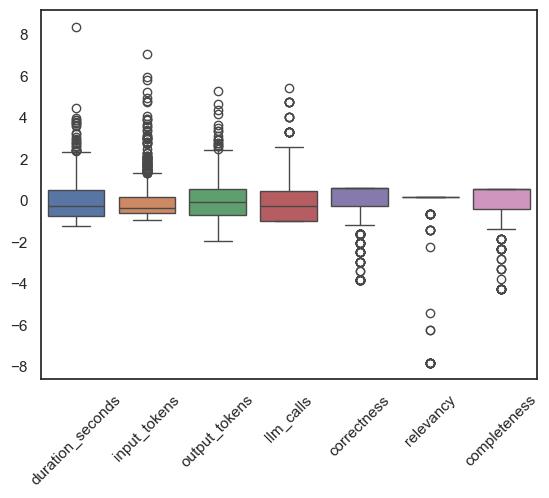

In [46]:
#check for anomalies
df_sel = df.loc[:,["duration_seconds", "input_tokens", "output_tokens", "llm_calls", "correctness", "relevancy", "completeness"]]
df_sel_norm = (df_sel - df_sel.mean()) / df_sel.std()
sns.boxplot(data=df_sel_norm)
plt.xticks(rotation=45)
;

In [45]:
df = df.loc[df["duration_seconds"] < 600, :].reset_index(drop=True)

## EDA

### Deep Eval metrics
Correctness, Relevancy & Completeness

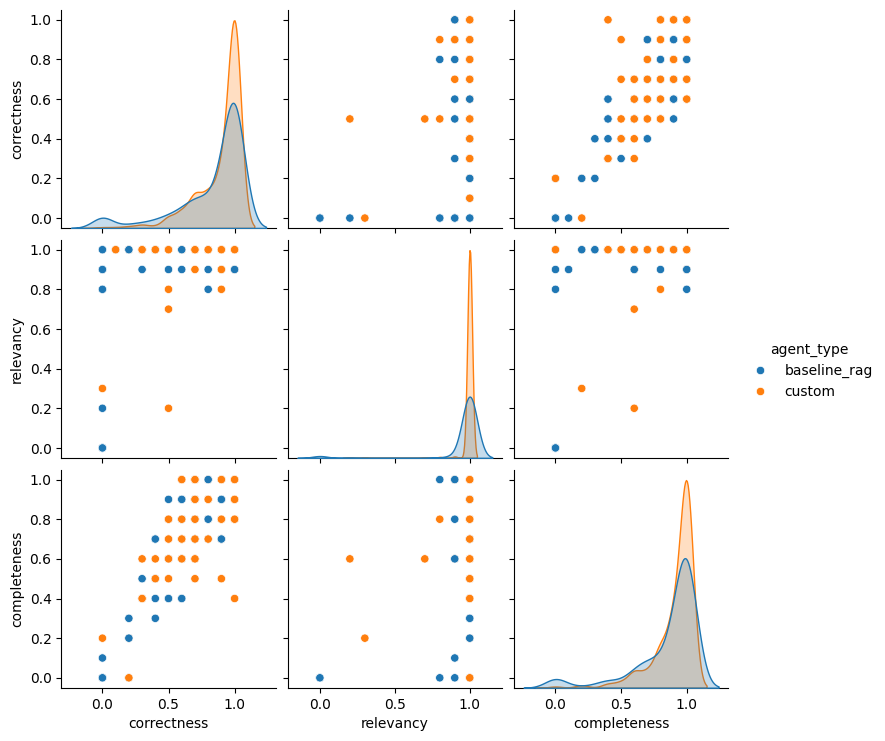

In [8]:
sns.pairplot(df[["correctness", "relevancy", "completeness", "llm_model", "agent_type"]], hue = "agent_type")
plt.savefig(f'../thesis/figures/deep_eval_pairplot.png') if save_figures else None

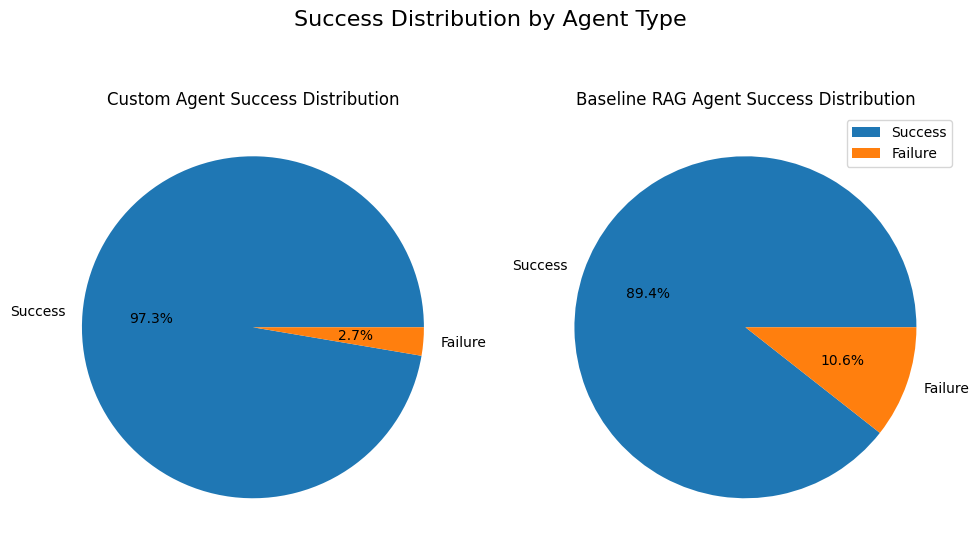

In [9]:
fig,ax = plt.subplots(figsize=(10,10),nrows = 1, ncols = 2)
ax[0].pie(df.loc[df["agent_type"] == "custom", "success"].value_counts(), labels = ["Success", "Failure"], autopct='%1.1f%%')
ax[0].set_title("Custom Agent Success Distribution")
ax[1].pie(df.loc[df["agent_type"] == "baseline_rag", "success"].value_counts(), labels = ["Success", "Failure"], autopct='%1.1f%%')
ax[1].set_title("Baseline RAG Agent Success Distribution")

plt.suptitle("Success Distribution by Agent Type", y = 0.8, fontsize = 16,)
plt.legend()
plt.tight_layout()
plt.savefig(f'../thesis/figures/deep_eval_success_distribution.png') if save_figures else None

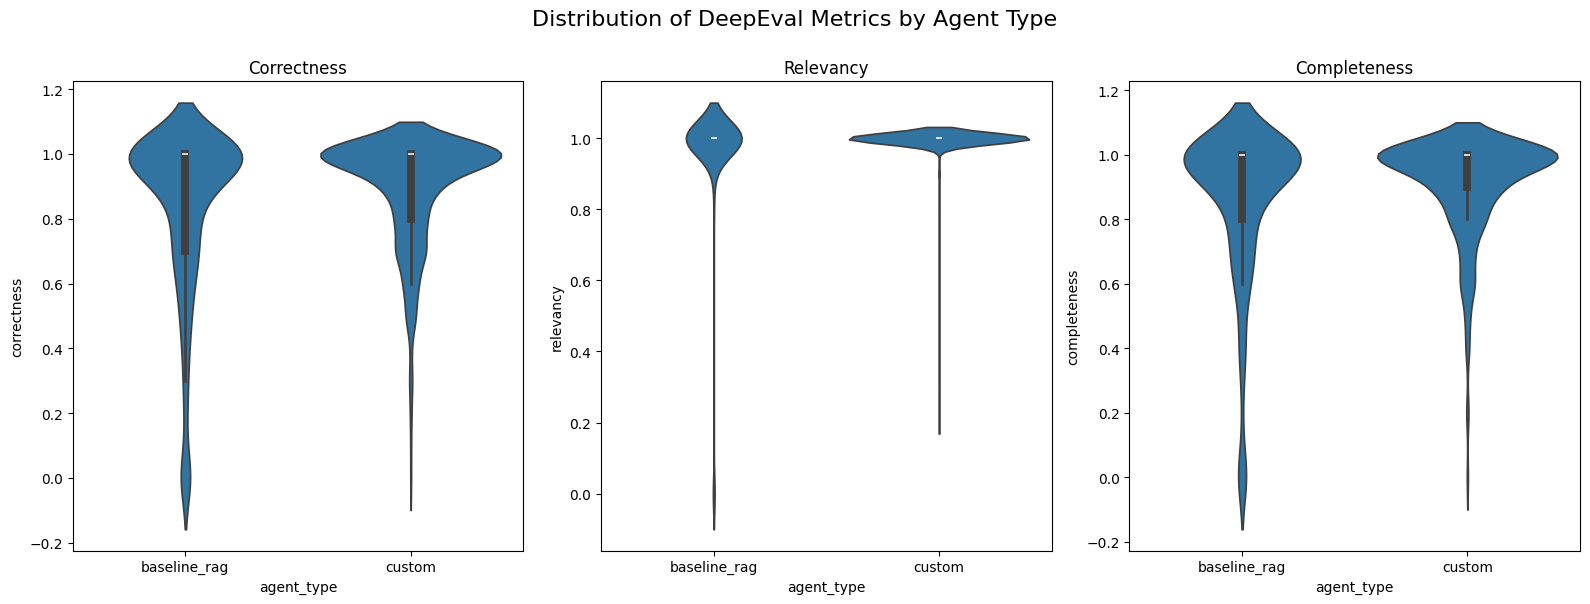

In [10]:
fig, ax = plt.subplots(figsize=(16, 6), ncols=3, nrows=1)
sns.violinplot(df, x = "agent_type", y = "correctness", ax=ax[0])
ax[0].set_title("Correctness")
sns.violinplot(df, x = "agent_type", y = "relevancy", ax=ax[1])
ax[1].set_title("Relevancy")
sns.violinplot(df, x = "agent_type", y = "completeness", ax=ax[2])
ax[2].set_title("Completeness")
plt.suptitle("Distribution of DeepEval Metrics by Agent Type", y = 1.0, fontsize = 16)
plt.tight_layout()
fig.savefig(f'../thesis/figures/deep_eval_violin.png') if save_figures else None

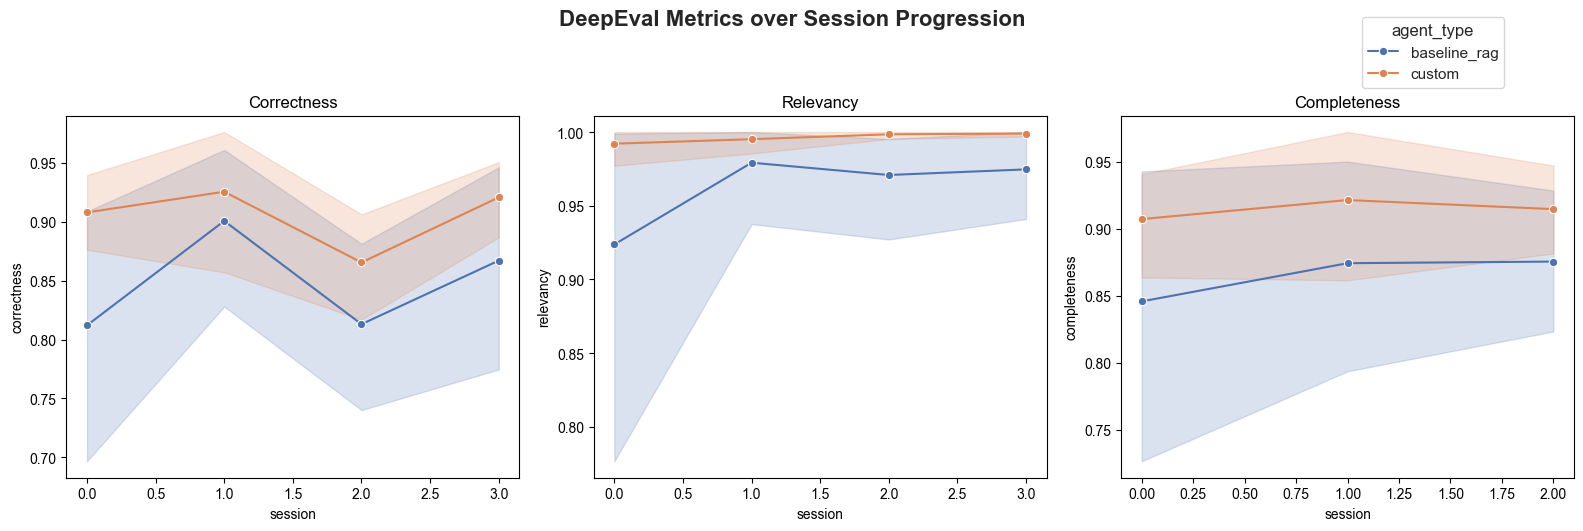

In [11]:
dfs = df.groupby(by = ["agent_type", "llm_model","dataset_name",  "session",],).agg({"correctness" : "mean", 
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",
                                                         "bert_f1" : "mean",
                                                         "s_bert_similarity" : "mean",
                                                         "duration_seconds" : "mean",
                                                         "input_tokens" : "mean",
                                                         "output_tokens" : "mean",
                                                         "total_tokens" : "mean"})

plot_df = dfs.reset_index().sort_values("session")

def session_plot_metrics(plot_df, metrics, fig_filename = None):
    fig, ax = plt.subplots(figsize=(16, 5), ncols=len(metrics), nrows=1)
    sns.set_theme(style="white")
    for metric in metrics:
         sns.lineplot(data=plot_df, x="session", y=metric, hue="agent_type", marker="o", ax=ax[metrics.index(metric)])
         ax[metrics.index(metric)].set_title(metric.capitalize())
    plt.suptitle("DeepEval Metrics over Session Progression", y=1.06, fontsize=16, fontweight="bold")
    handles, labels = ax[0].get_legend_handles_labels()   # hent fra første plot
    fig.legend(handles, labels, title="agent_type", loc="upper right", bbox_to_anchor=(0.95, 1.06))
    for a in ax:
        a.get_legend().remove()
    plt.tight_layout()
    if fig_filename and save_figures:
        plt.savefig(f'../thesis/figures/{fig_filename}.png')


def session_plot_by_dataset(plot_df, metric="correctness", save_fig = save_figures):
    agent_order = ["baseline_rag", "custom"] 
    palette = {"baseline_rag": "#1f77b4",     
            "custom": "#ff7f0e"} 
    fig, ax = plt.subplots(figsize=(15, 5), ncols=2)

    sns.lineplot(
        data=plot_df.loc[plot_df["dataset_name"] == "THRD-2021-163881"],
        x="session", 
        y=metric, 
        hue="agent_type",
        hue_order=agent_order, 
        palette=palette,
        marker="o", 
        ax=ax[0]
    )
    ax[0].set_title("THRD-2021-163881")

    sns.lineplot(
        data=plot_df.loc[plot_df["dataset_name"] == "TOSL-2024-125319-MIN"],
        x="session", 
        y=metric, 
        hue="agent_type",
        hue_order=agent_order,     
        palette=palette,     
        marker="o", 
        ax=ax[1]
    )
    ax[1].set_title("TOSL-2024-125319-MIN")

    plt.suptitle(f"{metric.capitalize()} over Session Progression by Dataset", y=1.05, fontsize=16, fontweight="bold")

    handles, labels = ax[0].get_legend_handles_labels()   # hent fra første plot
    fig.legend(handles, labels, title="agent_type", loc="upper right", bbox_to_anchor=(0.98, 1.03))

    ax[0].get_legend().remove()
    ax[1].get_legend().remove()

    plt.tight_layout()
    if save_fig:
        plt.savefig(f'../thesis/figures/lineplot_{metric}_by_dataset.png', dpi=300, bbox_inches='tight')


session_plot_metrics(plot_df, metrics = ["correctness", "relevancy", "completeness"], fig_filename = "deep_eval_lineplot")

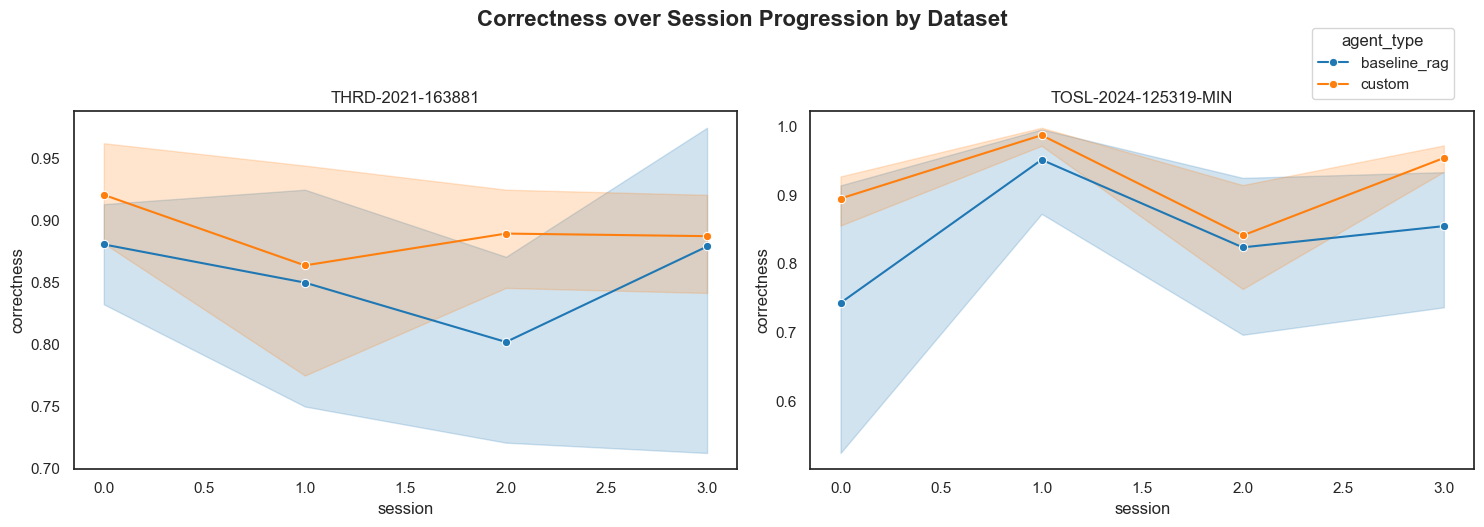

In [12]:
session_plot_by_dataset(plot_df, metric="correctness", save_fig = save_figures)

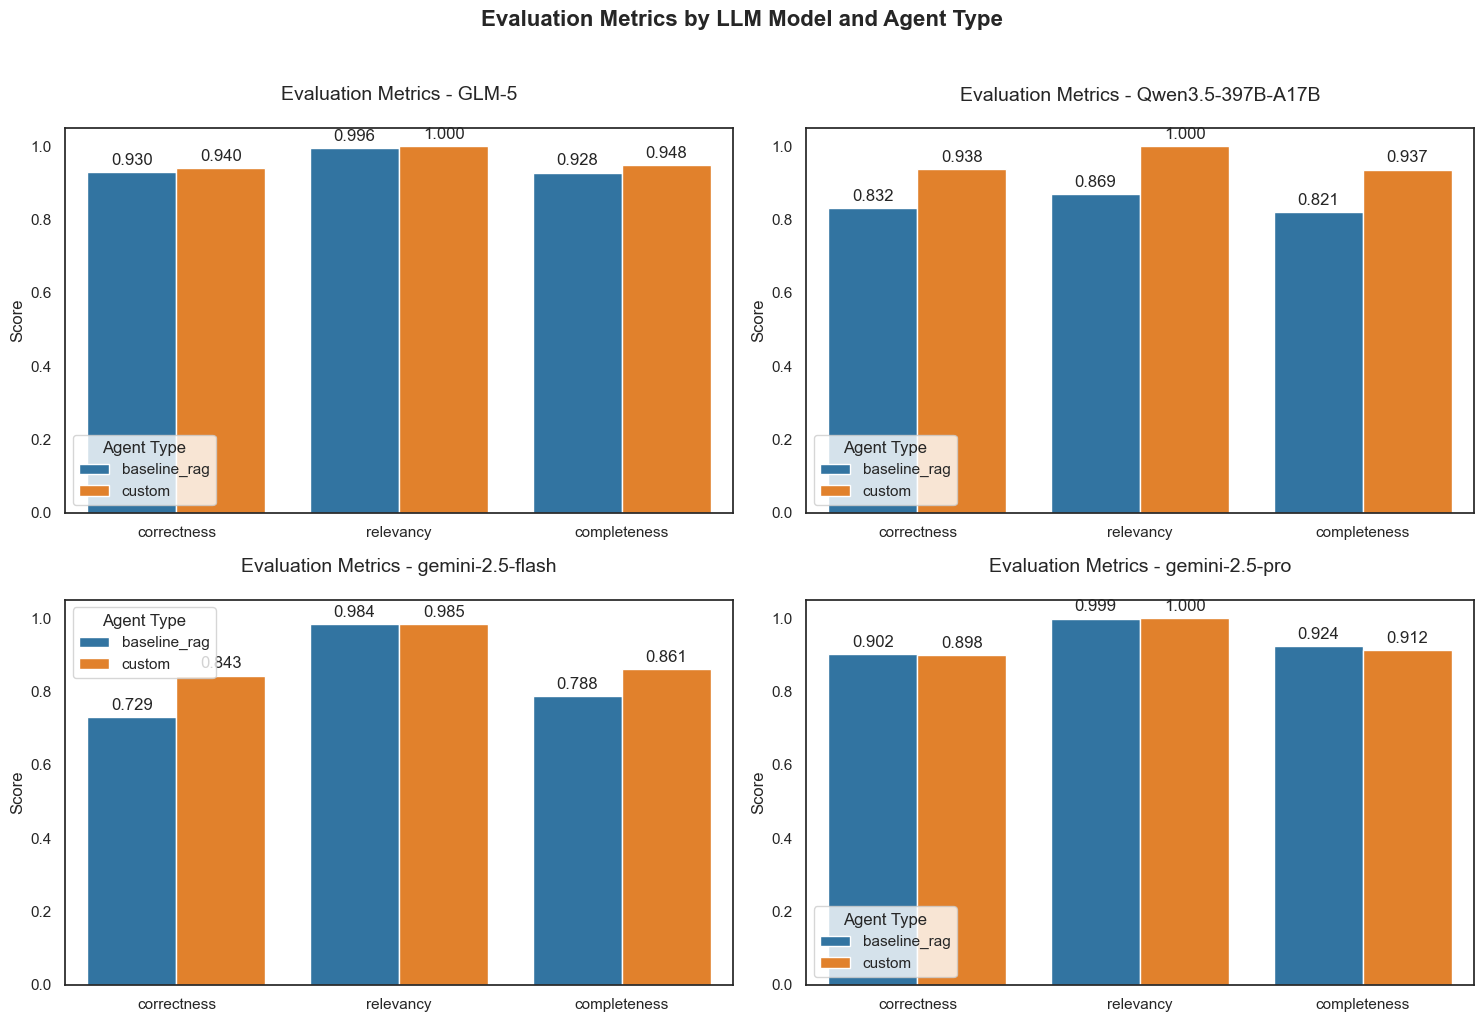

In [13]:

data = plot_df.groupby(by = ["llm_model", "agent_type"]).agg({"correctness" : "mean",
                                                         "relevancy" : "mean",
                                                         "completeness" : "mean",}).reset_index()
plot_data = data.melt(
    id_vars=['llm_model', 'agent_type'],
    value_vars=['correctness', 'relevancy', 'completeness'],
    var_name='metric',
    value_name='score'
)

nunique_models = plot_data["llm_model"].nunique()

fig,ax = plt.subplots(figsize=(15, 10), nrows = nunique_models // 2 + nunique_models % 2, ncols = 2)

for idx, model in enumerate(plot_data['llm_model'].unique()):
    row_idx = idx // 2
    col_idx = idx % 2
    model_data = plot_data[plot_data['llm_model'] == model]
        
    sns.barplot(
        data=model_data,
        x='metric',           # correctness, relevancy, completeness på x-aksen
        y='score',
        hue='agent_type',     # baseline_rag vs custom (to søyler per metric)
        palette=['#1f77b4', '#ff7f0e'],  # blå for baseline, oransje for custom
        dodge=True,
        ax=ax[row_idx, col_idx]
    )
    
    ax[row_idx, col_idx].set_title(f'Evaluation Metrics - {model}', fontsize=14, pad=20)
    ax[row_idx, col_idx].set_ylabel('Score')
    ax[row_idx, col_idx].set_xlabel('')
    ax[row_idx, col_idx].set_ylim(0, 1.05)
    ax[row_idx, col_idx].legend(title='Agent Type', title_fontsize=12)
    
    # Legg til verdier på toppen av søylene (valgfritt men veldig nyttig)
    for container in ax[row_idx, col_idx].containers:
        ax[row_idx, col_idx].bar_label(container, fmt='%.3f', padding=3)

plt.suptitle('Evaluation Metrics by LLM Model and Agent Type', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
fig.savefig(f'../thesis/figures/deep_eval_barplot_llms.png', 
            dpi=300, bbox_inches='tight',
            ) if save_figures else None

### Bert metrics

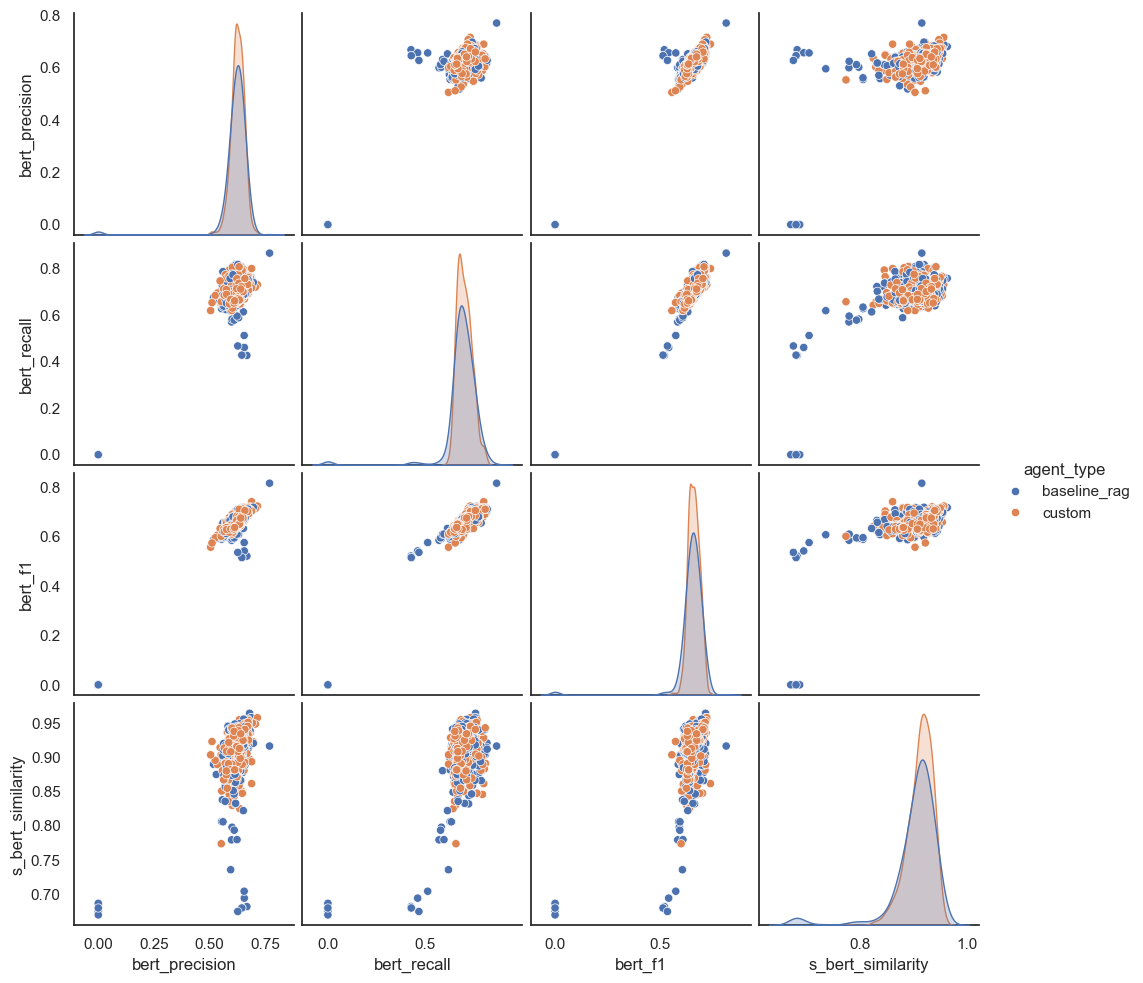

In [14]:
sns.pairplot(df[["bert_precision", "bert_recall", "bert_f1", "s_bert_similarity","llm_model", "agent_type"]], hue = "agent_type")
plt.savefig(f'../thesis/figures/bert_pairplot.png') if save_figures else None

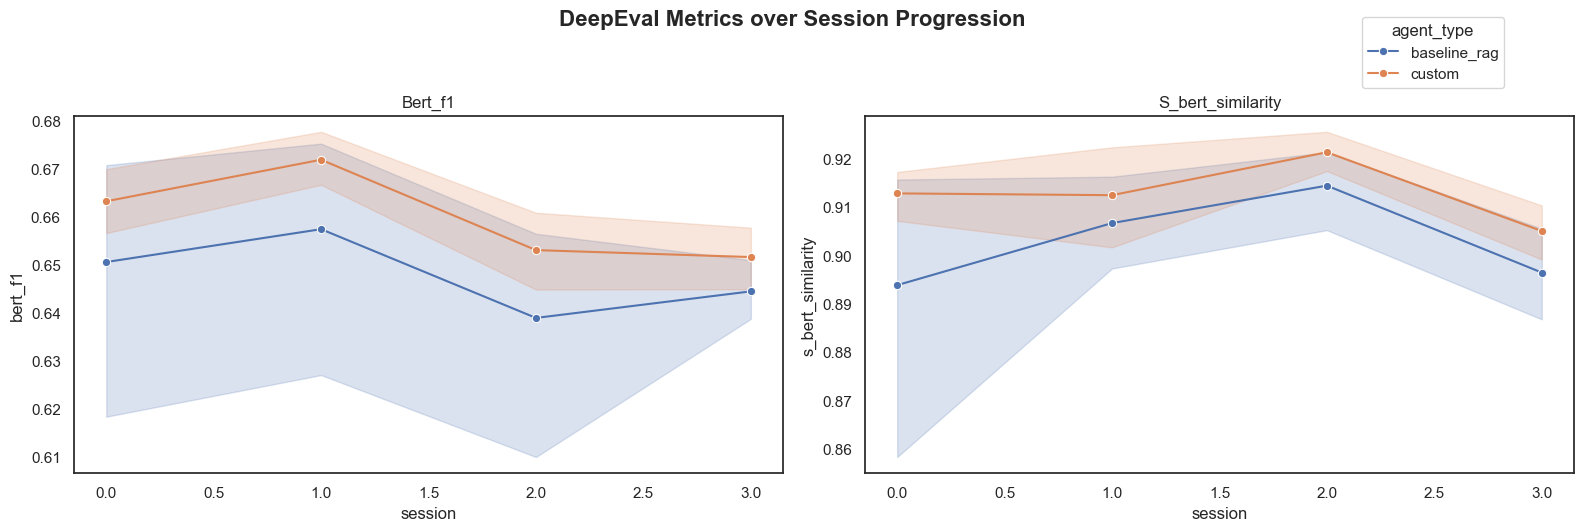

In [15]:
session_plot_metrics(plot_df, metrics = ["bert_f1", "s_bert_similarity"], fig_filename = "bert_lineplot")
plt.savefig(f'../thesis/figures/bert_lineplot.png') if save_figures else None

### Resource metrics
Token counts and time coutns

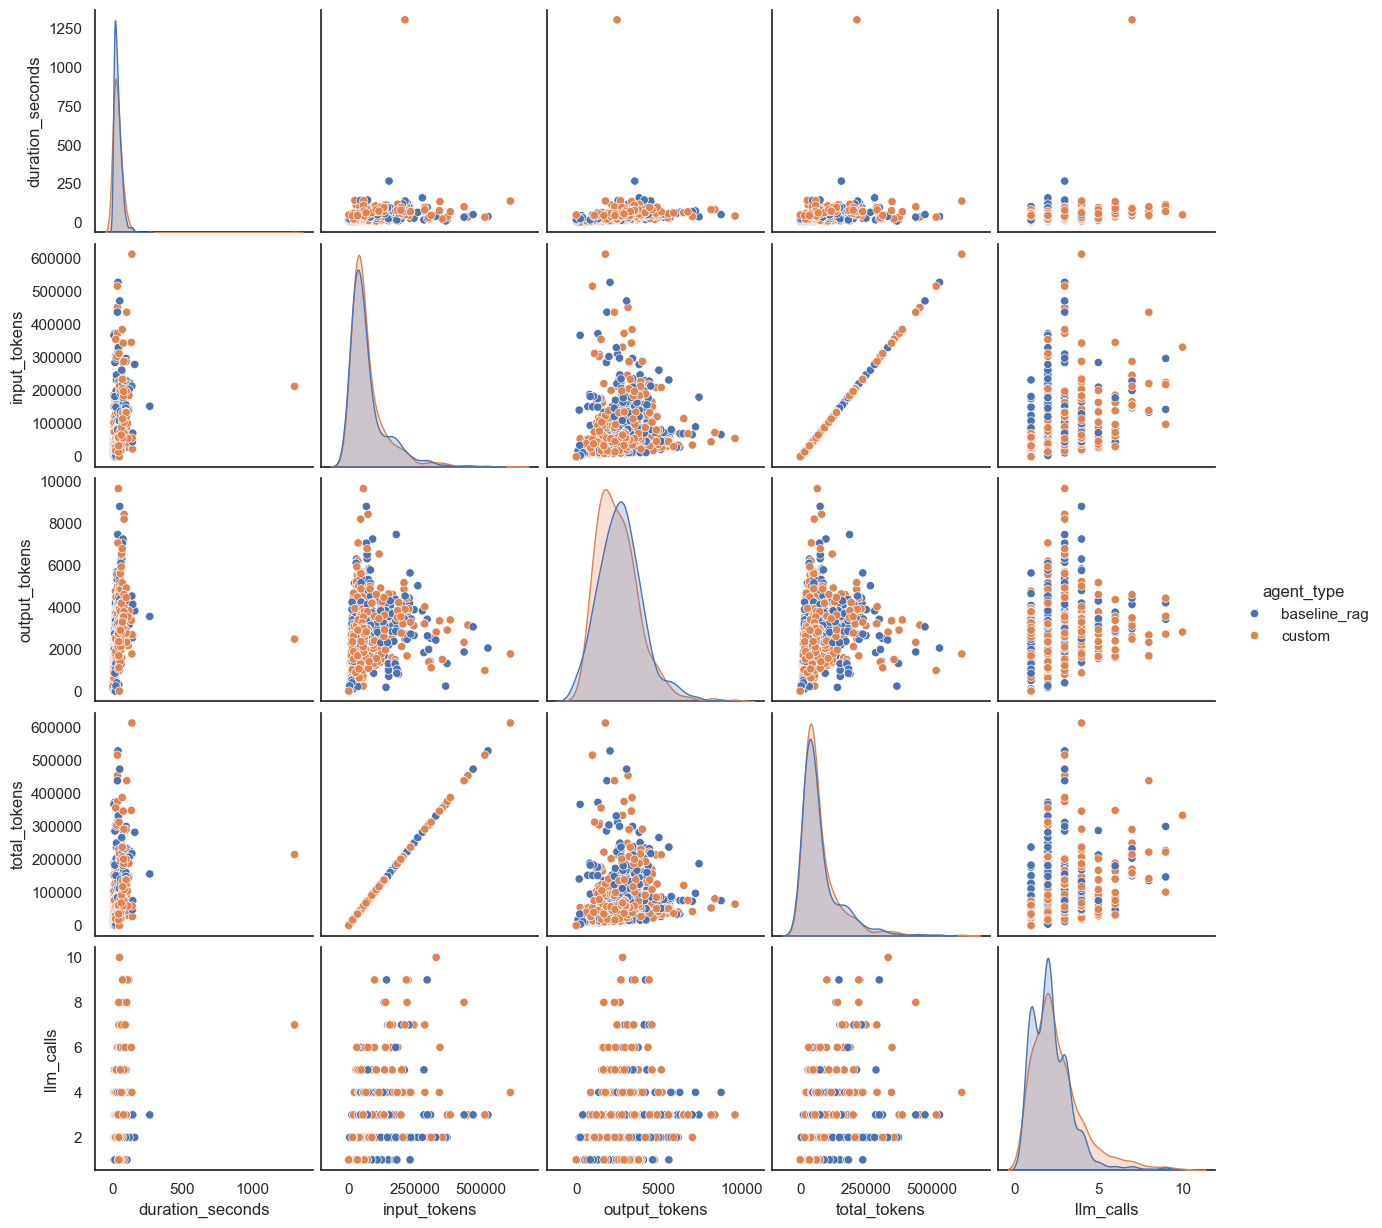

In [16]:
sns.pairplot(df[["duration_seconds", "input_tokens", "output_tokens", "total_tokens" , "llm_calls", "llm_model", "agent_type"]], hue = "agent_type")
plt.savefig(f'../thesis/figures/resource_pairplot.png') if save_figures else None

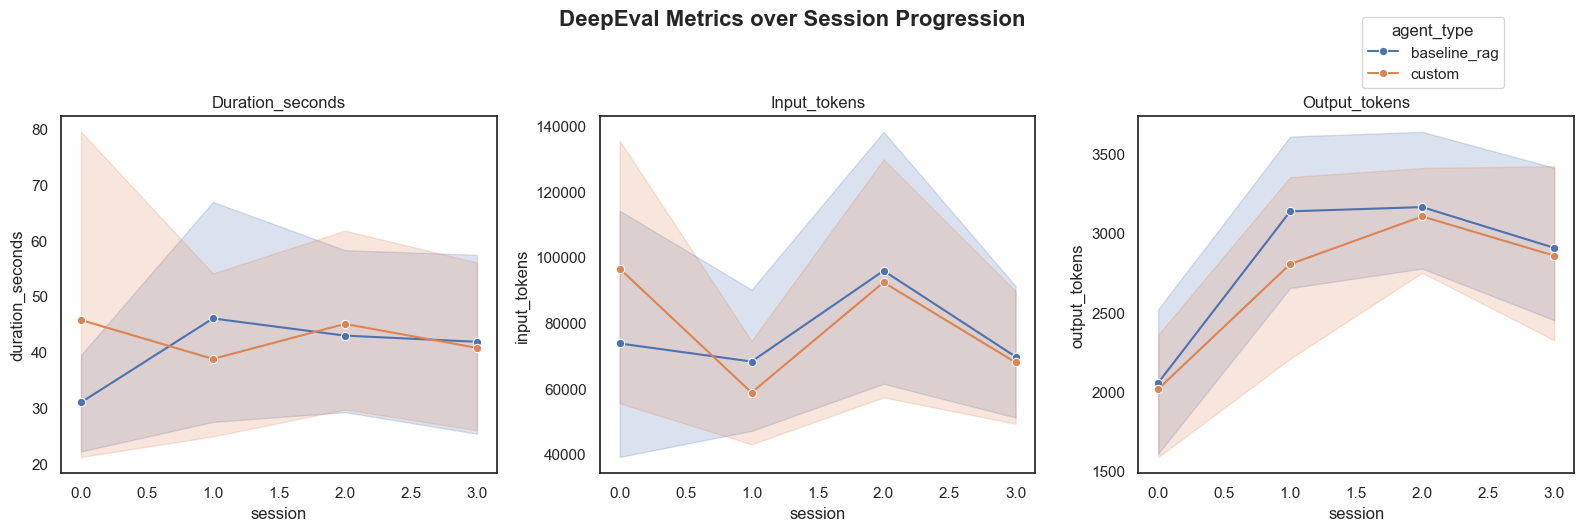

In [181]:
session_plot_metrics(plot_df, metrics = ["duration_seconds", "input_tokens", "output_tokens"], fig_filename = "resource_lineplot")
plt.savefig(f'../thesis/figures/resource_lineplot.png')

### Combined
Deep eval, bert & resource

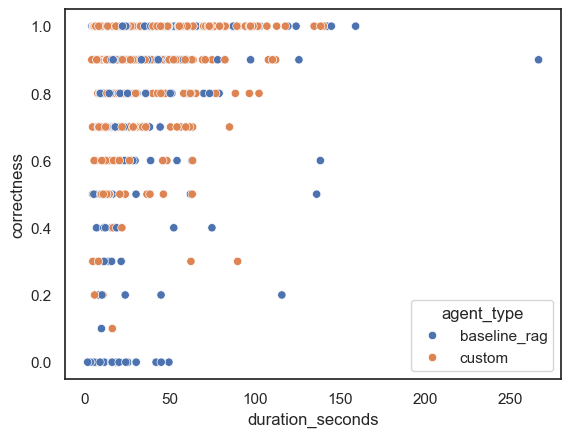

In [48]:
sns.scatterplot(df, x = "duration_seconds", y = "correctness", hue = "agent_type",)
plt.savefig(f'../thesis/figures/duration_vs_correctness.png') if save_figures else None

## Statistical Modeling

In [98]:
import numpy as np
from scipy import stats 

class StatisticalMetrics:
    def __init__(self, significance_level: float = 0.05):
        self.significance_level = significance_level

    def check_normality(self, values: list[float] | np.ndarray):
        """
        Performs Shapiro-Wilk test for normality.
        """
        result = stats.shapiro(values)
        is_normal = result.pvalue > self.significance_level
        status = "✅ Normal distribution" if is_normal else "❌ Not normal distribution"
        print(f"{status} (p={result.pvalue:.2e})")
        return is_normal

    def mann_whitney_u_test(self, group_a: list[float] | np.ndarray, group_b: list[float] | np.ndarray, alternative: Literal["greater","less","two-sided"] = 'greater'):
        """
        Non-parametric alternative to Independent T-test (for 2 groups).
        Does not assume normality.
        """
        u_stat, p = stats.mannwhitneyu(group_a, group_b, alternative=alternative)
        print(f"\n--- Mann-Whitney U Test (Non-parametric T-test) ---")
        print(f"U-statistic: {u_stat:.2f}, p-value: {p:.4e}")
        
        if p < self.significance_level:
            print(f"✅ Group A is significantly greater than Group B (p < {self.significance_level})")
        else:
            print(f"❌ No significant difference (p >= {self.significance_level})")
        return p

    def kruskal_wallis_test(self, *groups: list[float] | np.ndarray):
        """
        Non-parametric alternative to One-way ANOVA (for 3+ groups).
        Tests if at least one group comes from a different distribution.
        """
        h_stat, p = stats.kruskal(*groups)
        print(f"\n--- Kruskal-Wallis Test (Non-parametric ANOVA) ---")
        print(f"H-statistic: {h_stat:.2f}, p-value: {p:.4e}")
        
        if p < self.significance_level:
            print(f"✅ Significant difference exists between at least two groups.")
        else:
            print(f"❌ No significant difference between the groups.")
        return p

    def wilcoxon_signed_rank_test(self, before: list[float], after: list[float], alternative: Literal["greater","less","two-sided"] = 'greater'):
        """
        Non-parametric alternative to Paired T-test.
        Use this if the '0-1 values' are from the same subjects/items at different times.
        """
        stat, p = stats.wilcoxon(before, after, alternative=alternative)
        print(f"\n--- Wilcoxon Signed-Rank Test (Paired) ---")
        print(f"Statistic: {stat:.2f}, p-value: {p:.4e}")
        if p < self.significance_level:
            print(f"✅ 'After' is significantly greater than 'Before' (p < {self.significance_level})")
        else:
            print(f"❌ No significant difference (p >= {self.significance_level})")
        return p
    def t_test(self, custom_eval: list[float] | np.ndarray, comparison_eval: list[float] | np.ndarray, alternative: Literal["greater","less","two-sided"] = 'greater'):
        t_stat, p = stats.ttest_ind(custom_eval, comparison_eval, equal_var=False, alternative=alternative)
        print(f"Custom vs. Comparison: t={t_stat:.2f}, p={p:.4f}")
        if p < self.significance_level:
            print("✅ Custom beats Comparison (p<0.05).")
        else:
            print("❌ No significant difference (p>=0.05).")


In [50]:
from collections import Counter
df["agent_type"].value_counts()

agent_type
custom          449
baseline_rag    434
Name: count, dtype: int64

### Correctness

❌ Not normal distribution (p=4.34e-28)
❌ Not normal distribution (p=8.99e-42)
❌ Not normal distribution (p=2.09e-23)


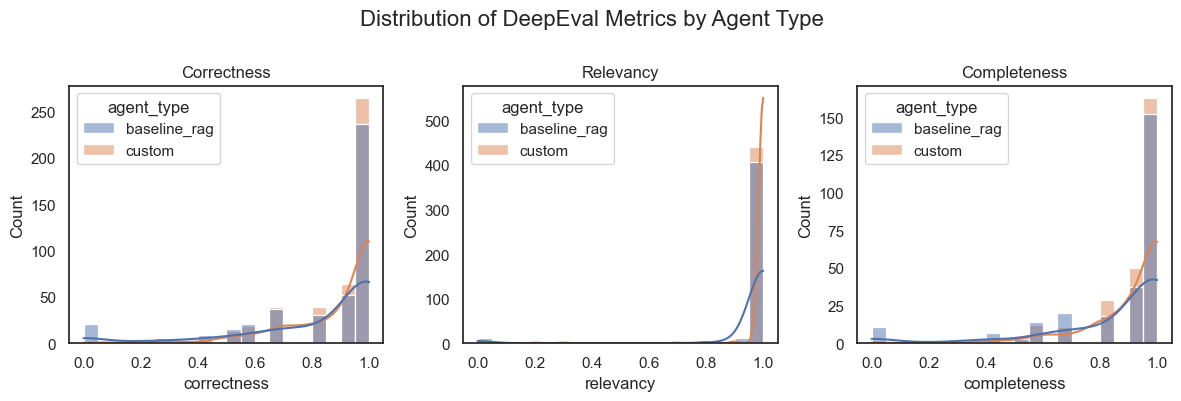

In [59]:
for metric in ["correctness", "relevancy", "completeness"]:
    StatisticalMetrics().check_normality(df.loc[df["agent_type"] == "custom", metric].dropna())
fig, ax = plt.subplots(figsize=(12, 4), ncols=3, nrows=1)
sns.histplot(df, x = "correctness", hue = "agent_type", kde = True, bins = 20, ax=ax[0])
ax[0].set_title("Correctness")
sns.histplot(df, x = "relevancy", hue = "agent_type", kde = True, bins = 20, ax=ax[1])
ax[1].set_title("Relevancy")
sns.histplot(df, x = "completeness", hue = "agent_type", kde = True, bins = 20, ax=ax[2])
ax[2].set_title("Completeness")
plt.suptitle("Distribution of DeepEval Metrics by Agent Type", y = 1.0, fontsize = 16)
plt.tight_layout()
plt.savefig(f'../thesis/figures/correctness_distribution.png') if save_figures else None

In [99]:
#Since not normally distributed, we use Mann-Whitney U test (non-parametric alternative to T-test)
sm = StatisticalMetrics()
for metric in ["correctness", "relevancy", "completeness"]:
    print(f"\nTesting metric: {metric}")
    custom_data = df.loc[df["agent_type"] == "custom", metric].dropna()
    rag_data = df.loc[df["agent_type"] == "baseline_rag", metric].dropna()
    sm.mann_whitney_u_test(group_a=custom_data, group_b=rag_data)


Testing metric: correctness

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 105587.00, p-value: 8.4911e-03
✅ Group A is significantly greater than Group B (p < 0.05)

Testing metric: relevancy

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 101782.50, p-value: 3.4208e-04
✅ Group A is significantly greater than Group B (p < 0.05)

Testing metric: completeness

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 38820.00, p-value: 8.3370e-02
❌ No significant difference (p >= 0.05)


❌ Not normal distribution (p=7.94e-28)
Avg, Std input_tokens for custom agent: 72285.89 ± 77114.40
Avg, Std input_tokens for baseline_rag agent: 71967.76 ± 75645.16


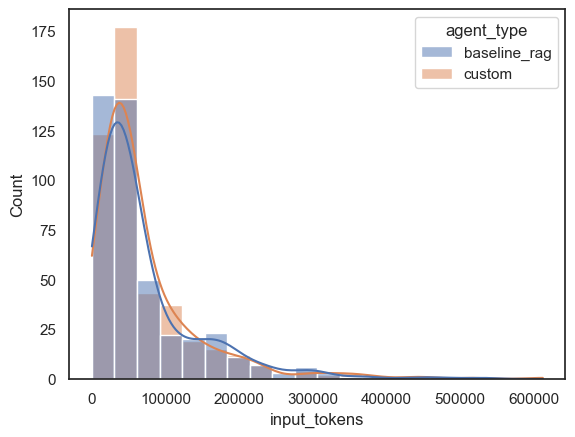

In [66]:
def check_metric(metric):
        StatisticalMetrics().check_normality(df.loc[df["agent_type"] == "custom", metric].dropna())
        print(f'Avg, Std {metric} for custom agent: {df.loc[df["agent_type"] == "custom", metric].mean():.2f} ± {df.loc[df["agent_type"] == "custom", metric].std():.2f}')
        print(f'Avg, Std {metric} for baseline_rag agent: {df.loc[df["agent_type"] == "baseline_rag", metric].mean():.2f} ± {df.loc[df["agent_type"] == "baseline_rag", metric].std():.2f}')
        sns.histplot(df, x = metric, hue = "agent_type", kde = True, bins = 20)

check_metric("input_tokens")

In [67]:
print(f"\nTesting metric: input_tokens")
custom_data = df.loc[df["agent_type"] == "custom", "input_tokens"].dropna()
rag_data = df.loc[df["agent_type"] == "baseline_rag", "input_tokens"].dropna()
sm.mann_whitney_u_test(group_a=custom_data, group_b=rag_data, alternative="less")


Testing metric: input_tokens

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 99750.00, p-value: 7.2962e-01
❌ No significant difference (p >= 0.05)


np.float64(0.7296215661059136)

❌ Not normal distribution (p=3.14e-18)
Avg, Std duration_seconds for custom agent: 35.05 ± 26.90
Avg, Std duration_seconds for baseline_rag agent: 36.05 ± 28.22


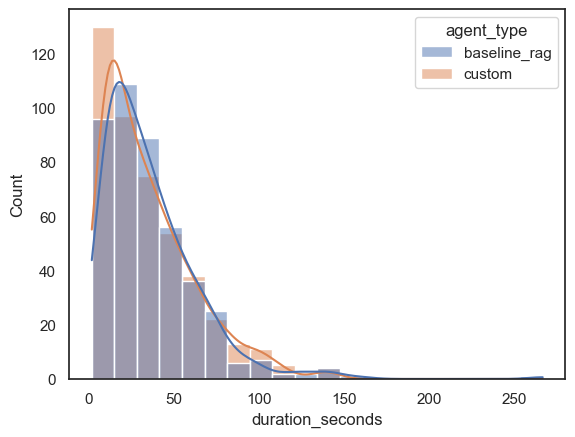

In [69]:
check_metric("duration_seconds")

In [70]:
print(f"\nTesting metric: duration_seconds")
custom_data = df.loc[df["agent_type"] == "custom", "duration_seconds"].dropna()
rag_data = df.loc[df["agent_type"] == "baseline_rag", "duration_seconds"].dropna()
sm.mann_whitney_u_test(group_a=custom_data, group_b=rag_data, alternative="less")


Testing metric: duration_seconds

--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 93705.00, p-value: 1.6260e-01
❌ No significant difference (p >= 0.05)


np.float64(0.16260286952854136)

### Self consistency

In [76]:
def pairwise_cosine_similarities(embeddings):
    """
    Tar inn en liste av embeddings (liste av list[float] eller array)
    Returnerer en matrise med alle pairwise cosine similarities
    """
    embeddings = [ast.literal_eval(emb) if isinstance(emb, str) else emb for emb in embeddings]
            
    emb = np.array(embeddings, dtype=float)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    normalized = emb / norms                     # L2-normaliser
    sim_matrix = normalized @ normalized.T       # alle mot alle
    return sim_matrix

def self_consistency_score(embeddings, method="mean"):
    """
    Regner ut en self-consistency score for en gruppe embeddings.
    
    method:
      - 'mean'     → gjennomsnitt av alle unike pairwise similarities (vanligst)
      - 'min'      → den laveste pairwise similarity (strengeste)
      - 'median'   → median av pairwise similarities
    """
    if len(embeddings) < 2:
        return 1.0  # kun én embedding → perfekt consistency
    
    sim_matrix = pairwise_cosine_similarities(embeddings)
    
    # Ta bare upper triangle (uten diagonal)
    triu_idx = np.triu_indices_from(sim_matrix, k=1)
    pairwise_sims = sim_matrix[triu_idx]
    
    if method == "mean":
        return float(pairwise_sims.mean())
    elif method == "median":
        return float(np.median(pairwise_sims))
    elif method == "min":
        return float(pairwise_sims.min())
    else:
        raise ValueError("method må være 'mean', 'median' eller 'min'")

In [77]:
embeddings = df.groupby(["llm_model", "query_id", "agent_type"])["embedded_actual_output"].apply(list)
embeddings = embeddings.to_frame(name="embedded_actual_output").reset_index()
embeddings["self_consistency"] = embeddings["embedded_actual_output"].apply(self_consistency_score)

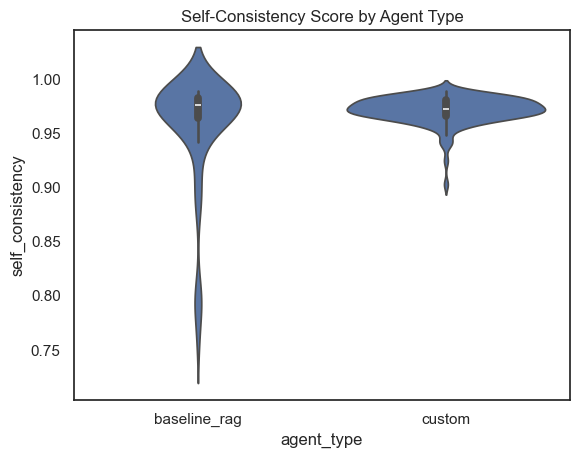

In [190]:
sns.violinplot(embeddings, x = "agent_type", y = "self_consistency")
plt.title("Self-Consistency Score by Agent Type")
plt.savefig(f'../thesis/figures/self_consistency_violin.png')

<Axes: xlabel='self_consistency', ylabel='Count'>

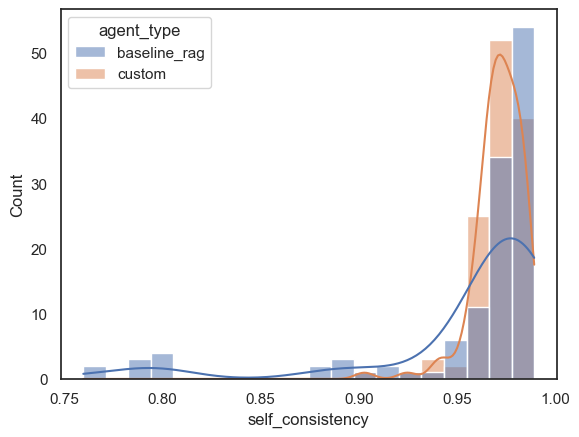

In [78]:
sns.histplot(embeddings, x = "self_consistency", hue = "agent_type", kde = True, bins = 20)

In [79]:
sm.mann_whitney_u_test(
    group_a=embeddings.loc[embeddings["agent_type"] == "custom", "self_consistency"].dropna(),
    group_b=embeddings.loc[embeddings["agent_type"] == "baseline_rag", "self_consistency"].dropna(),
    alternative="greater"
)


--- Mann-Whitney U Test (Non-parametric T-test) ---
U-statistic: 7089.00, p-value: 8.5573e-01
❌ No significant difference (p >= 0.05)


np.float64(0.8557344688799617)

## Variance analysis

In [89]:
def process_var_stats(metric,
                      df,
                      variances : dict[str,list[float]]):
    #print(f"\n{metric} - Custom Agent: mean={df.loc[df['agent_type'] == 'custom', metric].mean():.2f}, std={df.loc[df['agent_type'] == 'custom', metric].std():.2f}")
    #print(f"{metric} - Baseline RAG Agent: mean={df.loc[df['agent_type'] == 'baseline_rag', metric].mean():.2f}, std={df.loc[df['agent_type'] == 'baseline_rag', metric].std():.2f}")
    #custom_norm = (df.loc[df['agent_type'] == 'custom', metric] - df.loc[df['agent_type'] == 'custom', metric].mean()) / df.loc[df['agent_type'] == 'custom', metric].std()
    #rag_norm = (df.loc[df['agent_type'] == 'baseline_rag', metric] - df.loc[df['agent_type'] == 'baseline_rag', metric].mean()) / df.loc[df['agent_type'] == 'baseline_rag', metric].std()
    var_custom  = df.loc[df['agent_type'] == 'custom', metric].var()
    var_rag = df.loc[df['agent_type'] == 'baseline_rag', metric].var()
    string = f"{metric} - Variance of normalized values: Custom Agent={var_custom:.4f}, Baseline RAG Agent={var_rag:.4f}" + (f'✅' if var_custom < var_rag else f'❌')
    print(string)
    variances["custom"].append(var_custom)
    variances["baseline_rag"].append(var_rag)

In [90]:
#deep eval metrics
variances = {"custom": [], "baseline_rag": []}
for metric in ["correctness", "relevancy", "completeness"]:
    process_var_stats(df = df, metric = metric, variances = variances)

for metric in ["duration_seconds", "input_tokens"]:
    process_var_stats(df = df , metric = metric, variances = variances)

for metric in ["bert_f1", "s_bert_similarity"]:
    process_var_stats(df = df , metric = metric, variances = variances)

process_var_stats(df = embeddings, metric = "self_consistency", variances = variances)

correctness - Variance of normalized values: Custom Agent=0.0284, Baseline RAG Agent=0.0712✅
relevancy - Variance of normalized values: Custom Agent=0.0029, Baseline RAG Agent=0.0286✅
completeness - Variance of normalized values: Custom Agent=0.0241, Baseline RAG Agent=0.0611✅
duration_seconds - Variance of normalized values: Custom Agent=723.5035, Baseline RAG Agent=796.6452✅
input_tokens - Variance of normalized values: Custom Agent=5946630902.8564, Baseline RAG Agent=5722190970.9124❌
bert_f1 - Variance of normalized values: Custom Agent=0.0007, Baseline RAG Agent=0.0060✅
s_bert_similarity - Variance of normalized values: Custom Agent=0.0006, Baseline RAG Agent=0.0021✅
self_consistency - Variance of normalized values: Custom Agent=0.0002, Baseline RAG Agent=0.0028✅


In [103]:
custom_var = np.array(variances.get("custom", []))
custom_var = (custom_var - custom_var.mean()) / custom_var.std()
rag_var = np.array(variances.get("baseline_rag", []))
rag_var = (rag_var - rag_var.mean()) / rag_var.std()

In [102]:
sm.t_test(custom_eval = custom_var, comparison_eval = rag_var, alternative = "less")

Custom vs. Comparison: t=0.03, p=0.5107
❌ No significant difference (p>=0.05).
